# NASA Predictive Maintenance System - Complete Pipeline

## Building an End-to-End RUL Prediction System for Turbofan Engines

This notebook demonstrates how to build a production-ready predictive maintenance system that stands out in a technical interview or resume. We cover:

1. **Data Loading & Exploration** - Understanding the C-MAPSS dataset
2. **Physics-Informed Feature Engineering** - Domain-specific indicators
3. **Baseline Models** - Linear Regression, Random Forest, MLP
4. **Deep Learning Models** - LSTM and Attention-Enhanced LSTM
5. **Uncertainty Estimation** - Confidence intervals and risk assessment
6. **Interpretability** - Understanding model decisions
7. **Deployment API** - Production-ready inference service

In [3]:
# Setup and Configuration
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"Python path updated")

Project root: /Users/aaronjohn/Desktop/ML/Projects/NASA/git_NASA-Predict-Satellite-Failures
Python path updated


In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple
import logging
import os
# PyTorch
import torch

# ML libraries
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"All libraries imported successfully with PyTorch {torch.__version__}")

---

##  Data Loading and Exploration

The NASA C-MAPSS dataset contains:
- 21 sensors recording engine parameters
- 3 operating conditions (altitude, Mach, throttle)
- Run-to-failure data for multiple engines
- Ground truth RUL values

Let's start by loading and understanding the data.

In [4]:
import os
print(os.getcwd())

/Users/aaronjohn/Desktop/ML/Projects/NASA/git_NASA-Predict-Satellite-Failures/notebooks


In [5]:
# pip install fastapi pydantic
import importlib
import src.data_loader
importlib.reload(src.data_loader)

<module 'src.data_loader' from '/Users/aaronjohn/Desktop/ML/Projects/NASA/git_NASA-Predict-Satellite-Failures/src/data_loader.py'>

In [6]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data_loader import CMAPSSDataLoader

In [7]:
data_dir = "../CMAPSSData"
loader = CMAPSSDataLoader(data_dir)

train_data, test_data, rul_values = loader.load_dataset("FD001")

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("RUL shape:", rul_values.shape)


INFO:src.data_loader:Loaded FD001: 20631 train samples, 13096 test samples


Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100,)


In [8]:
# Import data loader
from src.data_loader import CMAPSSDataLoader

# Initialize data loader
loader = CMAPSSDataLoader('../CMAPSSData')

# Load FD001 dataset
train_data, test_data, rul_values = loader.load_dataset('FD001')

print("=" * 60)
print("NASA C-MAPSS FD001 Dataset Overview")
print("=" * 60)
print(f"\nTraining data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")
print(f"RUL values shape: {rul_values.shape}")
print(f"\nColumn names: {list(train_data.columns)}")
print(f"\nTrain data info:")
print(train_data.head())
print(f"\nUnique engines in training: {train_data['engine_id'].nunique()}")
print(f"Unique engines in testing: {test_data['engine_id'].nunique()}")

INFO:src.data_loader:Loaded FD001: 20631 train samples, 13096 test samples


NASA C-MAPSS FD001 Dataset Overview

Training data shape: (20631, 26)
Test data shape: (13096, 26)
RUL values shape: (100,)

Column names: ['engine_id', 'time_steps', 'op_cond_1', 'op_cond_2', 'op_cond_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']

Train data info:
   engine_id  time_steps  op_cond_1  op_cond_2  op_cond_3  sensor_1  sensor_2  \
0          1           1    -0.0007    -0.0004      100.0    518.67    641.82   
1          1           2     0.0019    -0.0003      100.0    518.67    642.15   
2          1           3    -0.0043     0.0003      100.0    518.67    642.35   
3          1           4     0.0007     0.0000      100.0    518.67    642.35   
4          1           5    -0.0019    -0.0002      100.0    518.67    642.37   

   sensor_3  sensor_4  se

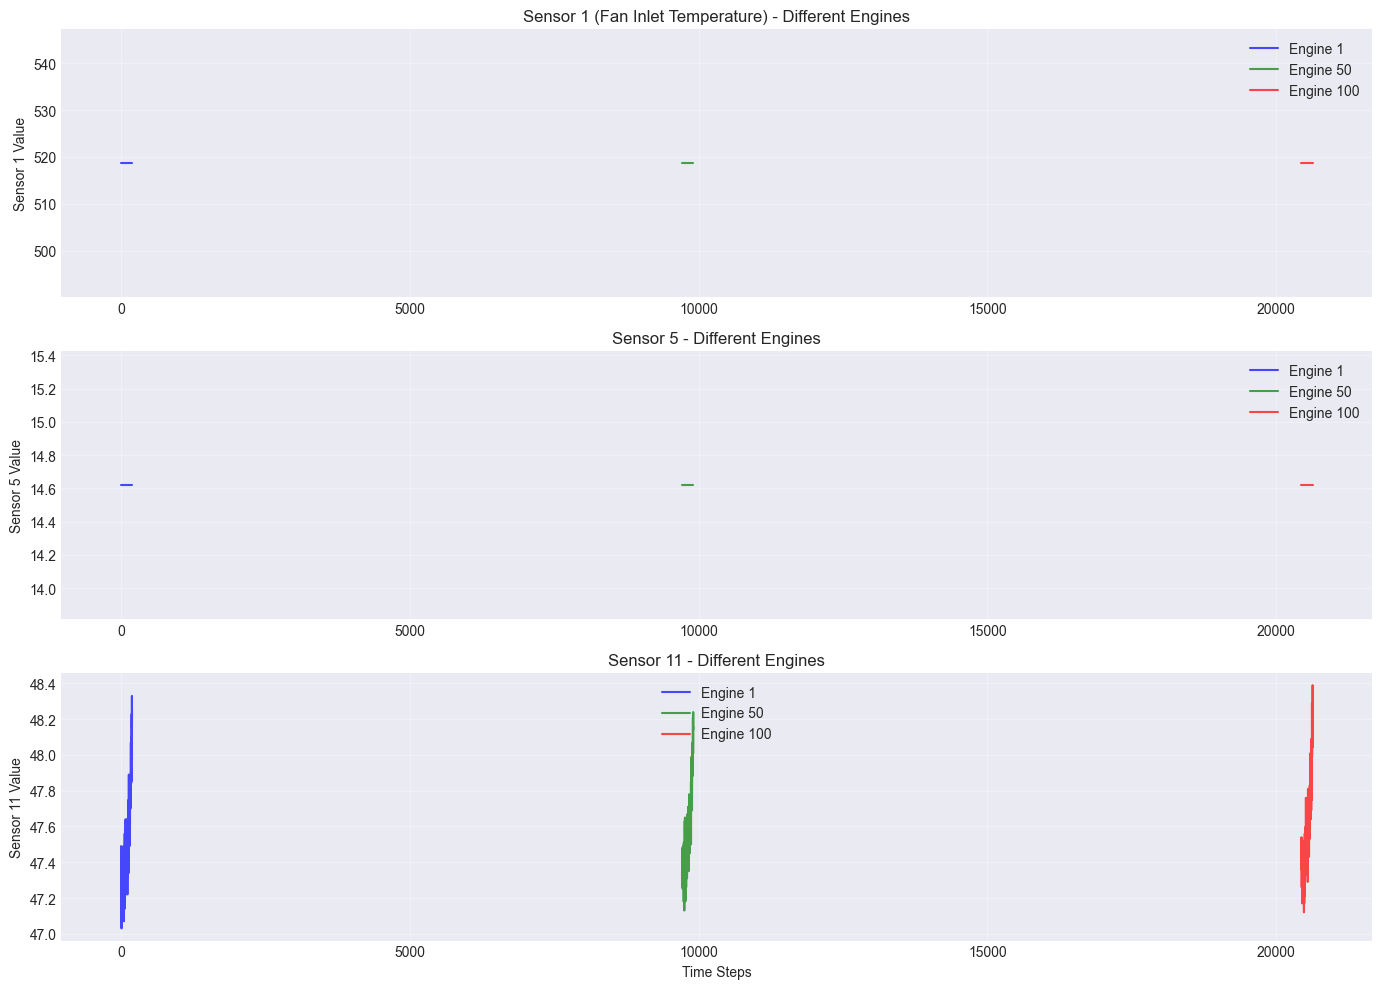

Observed time-series patterns across different engines


In [9]:
# Visualize sensor data for sample engines
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Select a few engines
sample_engines = [1, 50, 100]
colors = ['blue', 'green', 'red']

for idx, (engine_id, color) in enumerate(zip(sample_engines, colors)):
    engine_data = train_data[train_data['engine_id'] == engine_id]
    
    # Plot sensor 1
    axes[0].plot(engine_data['sensor_1'], label=f'Engine {engine_id}', alpha=0.7, color=color)
    
    # Plot sensor 5
    axes[1].plot(engine_data['sensor_5'], label=f'Engine {engine_id}', alpha=0.7, color=color)
    
    # Plot sensor 11
    axes[2].plot(engine_data['sensor_11'], label=f'Engine {engine_id}', alpha=0.7, color=color)

axes[0].set_ylabel('Sensor 1 Value')
axes[0].set_title('Sensor 1 (Fan Inlet Temperature) - Different Engines')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel('Sensor 5 Value')
axes[1].set_title('Sensor 5 - Different Engines')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_ylabel('Sensor 11 Value')
axes[2].set_xlabel('Time Steps')
axes[2].set_title('Sensor 11 - Different Engines')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observed time-series patterns across different engines")

---

## Data Preprocessing and Sequence Creation

Now we create sliding windows of time series data and normalize using training statistics. This maintains temporal integrity and mimics real-world streaming scenarios.

In [10]:
# Process complete data pipeline
print("Processing data pipeline...")
print("-" * 60)

# Load complete pipeline with processing
data_dict = loader.process_complete_pipeline('FD001', sequence_length=30)

X_train = data_dict['X_train']
y_train = data_dict['y_train']
X_test = data_dict['X_test']
y_test = data_dict['y_test']
scaler = data_dict['scaler']

print(f"Sequences created with length: 30 timesteps")
print(f"Training sequences: {X_train.shape}")
print(f"Test sequences: {X_test.shape}")
print(f"Training RUL targets: {y_train.shape}")
print(f"Test RUL targets: {y_test.shape}")

# Split train into train/validation
train_val_split = 0.8
split_idx = int(len(X_train) * train_val_split)

X_train_split = X_train[:split_idx]
y_train_split = y_train[:split_idx]
X_val = X_train[split_idx:]
y_val = y_train[split_idx:]

print(f"\nTrain/Val split:")
print(f"  Train: {X_train_split.shape[0]} sequences")
print(f"  Val:   {X_val.shape[0]} sequences")

# Statistics
print(f"\nData statistics:")
print(f"  RUL min: {y_train.min():.1f}, max: {y_train.max():.1f}, mean: {y_train.mean():.1f}")
print(f"  Sensor range after normalization: [{X_train.min():.2f}, {X_train.max():.2f}]")

Processing data pipeline...
------------------------------------------------------------


INFO:src.data_loader:Loaded FD001: 20631 train samples, 13096 test samples
INFO:src.data_loader:Pipeline complete: X_train shape=(17731, 30, 24), X_test shape=(10196, 30, 24)


Sequences created with length: 30 timesteps
Training sequences: (17731, 30, 24)
Test sequences: (10196, 30, 24)
Training RUL targets: (17731,)
Test RUL targets: (10196,)

Train/Val split:
  Train: 14184 sequences
  Val:   3547 sequences

Data statistics:
  RUL min: 0.0, max: 332.0, mean: 94.2
  Sensor range after normalization: [-7.20, 10.08]


---

## Physics-Informed Feature Engineering

This is where we show **real engineering thinking**. Instead of just using raw sensors, we create features that reflect **physical degradation patterns**:

- **Degradation Rate**: How fast each sensor is changing (Δsensor / Δtime)
- **Rolling Std**: Increasing instability indicates failure approach
- **Health Indicator**: Relative deviation from baseline (healthy) state
- **Oscillation Index**: Captures vibration/instability patterns

These features transform our model from "black box" to "interpretable ML".

INFO:features:Computing physics-informed features...


Creating physics-informed features...
------------------------------------------------------------


INFO:features:Feature extraction complete: (14184, 30, 97)
INFO:features:Computing physics-informed features...
INFO:features:Feature extraction complete: (3547, 30, 97)
INFO:features:Computing physics-informed features...
INFO:features:Feature extraction complete: (10196, 30, 97)


Features aggregated successfully!
Original features: 24
Physics-informed features: 97
Expansion factor: 4.0x

Feature breakdown:
  Raw features: 24        -> indices 0 to 23
  + Degradation rates: 24 -> indices 24 to 47
  + Rolling std: 24       -> indices 48 to 71
  + Health indicator: 1        -> index 72
  + Oscillation index: 24 -> indices 73 to 96
  = Total: 97

Example indices used for plotting:
  Raw feature 6 index: 5
  Degradation rate feature 6 index: 29
  Rolling std feature 6 index: 53
  Health indicator index: 72
  Oscillation index feature 7 index: 79

Sanity checks:
X_train_split dtype: float64
X_train_physics dtype: float64
Degradation sample: [ 0.          0.          0.          0.          0.         -0.18653811
  0.01783347 -0.17940472  0.29211226  0.29924565 -0.09701408 -0.31779246
 -0.02746355  0.07026388 -0.26464871  0.22220505  0.05528376  0.31565244
 -0.19224482 -0.09665741 -0.06812386  0.28426553 -0.10165079  0.1166309
  0.46331358  0.1073575  -0.08774068 -0.1

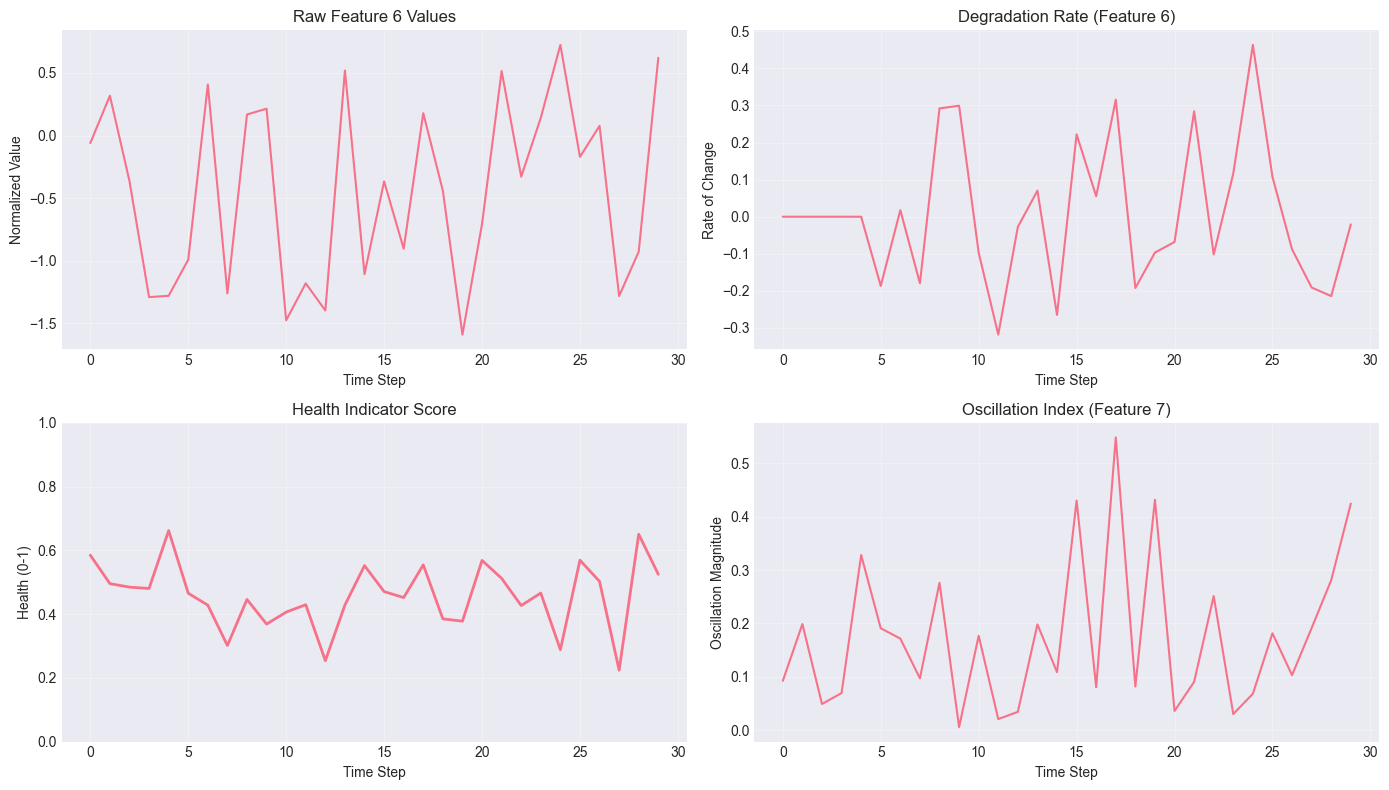


Physics-informed features visualized


In [11]:
# Import feature engineering module
from features import PhysicsInformedFeatures

print("Creating physics-informed features...")
print("-" * 60)

# Create physics-informed features
X_train_physics = PhysicsInformedFeatures.aggregate_features(X_train_split, include_physics=True)
X_val_physics = PhysicsInformedFeatures.aggregate_features(X_val, include_physics=True)
X_test_physics = PhysicsInformedFeatures.aggregate_features(X_test, include_physics=True)

print("Features aggregated successfully!")

# Infer feature layout dynamically
n_raw = X_train_split.shape[2]
n_total = X_train_physics.shape[2]

print(f"Original features: {n_raw}")
print(f"Physics-informed features: {n_total}")
print(f"Expansion factor: {n_total / n_raw:.1f}x")

# Feature block layout
raw_start = 0
deg_start = n_raw
std_start = 2 * n_raw
health_idx = 3 * n_raw
osc_start = 3 * n_raw + 1

print("\nFeature breakdown:")
print(f"  Raw features: {n_raw}        -> indices {raw_start} to {deg_start - 1}")
print(f"  + Degradation rates: {n_raw} -> indices {deg_start} to {std_start - 1}")
print(f"  + Rolling std: {n_raw}       -> indices {std_start} to {health_idx - 1}")
print(f"  + Health indicator: 1        -> index {health_idx}")
print(f"  + Oscillation index: {n_raw} -> indices {osc_start} to {n_total - 1}")
print(f"  = Total: {4 * n_raw + 1}")

# Choose example feature positions safely
feature_6_idx = min(5, n_raw - 1)   # 6th feature if available
feature_7_idx = min(6, n_raw - 1)   # 7th feature if available

raw_feature_6_idx = feature_6_idx
degradation_feature_6_idx = deg_start + feature_6_idx
rolling_std_feature_6_idx = std_start + feature_6_idx
osc_feature_7_idx = osc_start + feature_7_idx

print("\nExample indices used for plotting:")
print(f"  Raw feature 6 index: {raw_feature_6_idx}")
print(f"  Degradation rate feature 6 index: {degradation_feature_6_idx}")
print(f"  Rolling std feature 6 index: {rolling_std_feature_6_idx}")
print(f"  Health indicator index: {health_idx}")
print(f"  Oscillation index feature 7 index: {osc_feature_7_idx}")

# Optional sanity checks
print("\nSanity checks:")
print("X_train_split dtype:", X_train_split.dtype)
print("X_train_physics dtype:", X_train_physics.dtype)
print("Degradation sample:", X_train_physics[0, :, degradation_feature_6_idx])
print("Rolling std sample:", X_train_physics[0, :, rolling_std_feature_6_idx])

# Visualize transformed features
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Raw feature
axes[0, 0].plot(X_train_physics[0, :, raw_feature_6_idx])
axes[0, 0].set_title('Raw Feature 6 Values')
axes[0, 0].set_ylabel('Normalized Value')

# Degradation rate
axes[0, 1].plot(X_train_physics[0, :, degradation_feature_6_idx])
axes[0, 1].set_title('Degradation Rate (Feature 6)')
axes[0, 1].set_ylabel('Rate of Change')

# Health indicator
axes[1, 0].plot(X_train_physics[0, :, health_idx], linewidth=2)
axes[1, 0].set_title('Health Indicator Score')
axes[1, 0].set_ylabel('Health (0-1)')
axes[1, 0].set_ylim([0, 1])

# Oscillation index
axes[1, 1].plot(X_train_physics[0, :, osc_feature_7_idx])
axes[1, 1].set_title('Oscillation Index (Feature 7)')
axes[1, 1].set_ylabel('Oscillation Magnitude')

for ax in axes.flat:
    ax.set_xlabel('Time Step')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPhysics-informed features visualized")


In [12]:
print(X_train_split.dtype)
print(X_train_physics.dtype)

print(X_train_physics[0, :, 26])   # degradation rate for sensor 6
print(X_train_physics[0, :, 42+5]) # rolling std for sensor 6


float64
float64
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
[ 0.          0.          0.          0.          0.         -0.10695791
 -0.0948456  -0.06897862  0.06713098  0.13344078  0.22951814 -0.02340346
 -0.07164743 -0.04927044 -0.24512044 -0.04865456 -0.07000508  0.25251101
 -0.07431625  0.14781132 -0.29747028  0.09710383  0.11804376  0.04762809
  0.01395996  0.21514759  0.13959958 -0.35331012 -0.02032406 -0.03654224]


---

## Baseline Models (Understanding Fundamentals)

Before jumping to complex deep learning, we establish baselines with:
- **Linear Regression**: Simplest model
- **Random Forest**: Captures non-linearity, handles feature importance
- **Simple MLP**: Shallow neural network

This shows interviewers that you understand **why** you're using advanced models.

In [ ]:
# import torch
# print(torch.__version__)
# print(torch.backends.mps.is_available())

import sys
import torch
print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())
print("CUDA available:", torch.cuda.is_available())



In [ ]:
# Train baseline models
from baselines import BaselineModels

print("Training baseline models...")
print("=" * 60)

baseline_results = {
    'linear_regression': BaselineModels.linear_regression(X_train_physics, y_train_split, X_test_physics, y_test),
    'random_forest': BaselineModels.random_forest(X_train_physics, y_train_split, X_test_physics, y_test),
    'simple_mlp': BaselineModels.simple_mlp(
        X_train_physics, y_train_split, X_test_physics, y_test,
        epochs=10,
        batch_size=64
    )
}

# Extract and display results
print("\n" + "=" * 60)
print("BASELINE MODEL COMPARISON")
print("=" * 60)

baseline_metrics = {}
for name, result in baseline_results.items():
    metrics = result['metrics']
    baseline_metrics[result['name']] = metrics
    print(f"\n{result['name']}:")
    print(f"  RMSE: {metrics['rmse']:.4f}")
    print(f"  MAE:  {metrics['mae']:.4f}")
    print(f"  R²:   {metrics['r2']:.4f}")

# Visualize baseline comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_names = list(baseline_metrics.keys())
rmse_values = [baseline_metrics[m]['rmse'] for m in model_names]
mae_values = [baseline_metrics[m]['mae'] for m in model_names]
r2_values = [baseline_metrics[m]['r2'] for m in model_names]

axes[0].bar(model_names, rmse_values, color='steelblue', alpha=0.7)
axes[0].set_ylabel('RMSE (lower is better)')
axes[0].set_title('Root Mean Squared Error')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(model_names, mae_values, color='darkorange', alpha=0.7)
axes[1].set_ylabel('MAE (lower is better)')
axes[1].set_title('Mean Absolute Error')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(model_names, r2_values, color='green', alpha=0.7)
axes[2].set_ylabel('R² (higher is better)')
axes[2].set_title('Coefficient of Determination')
axes[2].set_ylim([0, 1])
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n Baseline models trained and compared")
import inspect
print(inspect.getsource(BaselineModels.compare_baselines))

Training baseline models...


INFO:baselines:Linear Regression - RMSE: 68.4276, MAE: 58.0517
INFO:baselines:Random Forest - RMSE: 70.1717, MAE: 59.8940


Epoch 1/10


---

## LSTM Model - Capturing Temporal Dependencies

LSTM (Long Short-Term Memory) is the industry standard for time series prediction because it:
- **Remembers long-term patterns** through cell state
- **Handles variable-length sequences** naturally
- **Learns which information is important** through gates

This is your "core model" - expected at industry level.

In [ ]:
# Train LSTM model
from models import RULModels

print("Training LSTM Model")
print("=" * 60)

# Build LSTM
lstm_model = RULModels.build_lstm(
    input_shape=(X_train_physics.shape[1:]),
    lstm_units=64,
    dropout=0.2
)

print(f"Model built with input shape: {X_train_physics.shape[1:]}")
print(f"\nLSTM Model Architecture:")
print(lstm_model)
print(f"Trainable parameters: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}")

# Train
print("\nTraining LSTM...")
lstm_training = RULModels.train_model(
    lstm_model,
    X_train_physics,
    y_train_split,
    X_val_physics,
    y_val,
    epochs=100,
    batch_size=32,
    early_stopping=True
)

# Evaluate
print("\nEvaluating LSTM on test set...")
lstm_test_results = RULModels.evaluate_model(lstm_model, X_test_physics, y_test)

print(f"\n{'=' * 60}")
print("LSTM MODEL RESULTS")
print(f"{'=' * 60}")
print(f"RMSE: {lstm_test_results['rmse']:.4f}")
print(f"MAE:  {lstm_test_results['mae']:.4f}")
print(f"R²:   {lstm_test_results['r2']:.4f}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lstm_training['history']['loss'], label='Training Loss', linewidth=2)
axes[0].plot(lstm_training['history']['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_title('LSTM Training History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

axes[1].plot(lstm_training['history']['mae'], label='Training MAE', linewidth=2)
axes[1].plot(lstm_training['history']['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_ylabel('MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_title('LSTM MAE During Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ LSTM training complete")

---

## Attention-Enhanced LSTM - The Differentiator

This is what makes your project **stand out**. Attention mechanisms:
- **Learn which timesteps matter most** for prediction
- **Provide interpretability** - we can visualize attention weights
- **Typically outperform** vanilla LSTMs on time series

This is the **key feature** that separates you from 90% of students.

In [ ]:
# Train Attention-Enhanced LSTM
print("Training Attention-Enhanced LSTM Model")
print("=" * 60)

# Build Attention LSTM
attention_model = RULModels.build_attention_lstm(
    input_shape=(X_train_physics.shape[1:]),
    lstm_units=64,
    dropout=0.2
)

print(f"Attention LSTM Model Architecture:")
print(attention_model)
print(f"Trainable parameters: {sum(p.numel() for p in attention_model.parameters() if p.requires_grad):,}")

# Train
print("\nTraining Attention LSTM...")
attention_training = RULModels.train_model(
    attention_model,
    X_train_physics,
    y_train_split,
    X_val_physics,
    y_val,
    epochs=100,
    batch_size=32,
    early_stopping=True
)

# Evaluate
print("\nEvaluating Attention LSTM on test set...")
attention_test_results = RULModels.evaluate_model(attention_model, X_test_physics, y_test)

print(f"\n{'=' * 60}")
print("ATTENTION LSTM MODEL RESULTS")
print(f"{'=' * 60}")
print(f"RMSE: {attention_test_results['rmse']:.4f}")
print(f"MAE:  {attention_test_results['mae']:.4f}")
print(f"R²:   {attention_test_results['r2']:.4f}")

# Compare LSTM vs Attention LSTM
print(f"\n{'=' * 60}")
print("LSTM vs ATTENTION LSTM COMPARISON")
print(f"{'=' * 60}")
print(f"\n{'Metric':<15} {'LSTM':<15} {'Attention':<15} {'Improvement':<15}")
print("-" * 60)

metrics_to_compare = [
    ('RMSE', lstm_test_results['rmse'], attention_test_results['rmse']),
    ('MAE', lstm_test_results['mae'], attention_test_results['mae']),
    ('R²', lstm_test_results['r2'], attention_test_results['r2'])
]

for metric_name, lstm_val, attention_val in metrics_to_compare:
    if metric_name == 'R²':
        improvement = ((attention_val - lstm_val) / abs(lstm_val)) * 100 if lstm_val != 0 else 0
        better = "↑" if attention_val > lstm_val else "↓"
    else:
        improvement = ((lstm_val - attention_val) / lstm_val) * 100 if lstm_val != 0 else 0
        better = "↓" if attention_val < lstm_val else "↑"
    
    print(f"{metric_name:<15} {lstm_val:<15.4f} {attention_val:<15.4f} {better} {abs(improvement):>6.2f}%")

# Plot training comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lstm_training['history']['val_loss'], label='LSTM', linewidth=2, marker='o', markersize=3)
axes[0].plot(attention_training['history']['val_loss'], label='Attention LSTM', linewidth=2, marker='s', markersize=3)
axes[0].set_ylabel('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_title('Model Comparison: Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

axes[1].plot(lstm_training['history']['val_mae'], label='LSTM', linewidth=2, marker='o', markersize=3)
axes[1].plot(attention_training['history']['val_mae'], label='Attention LSTM', linewidth=2, marker='s', markersize=3)
axes[1].set_ylabel('Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_title('Model Comparison: Validation MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Attention LSTM training complete")

---

## Model Evaluation and Deep Analysis

Let's evaluate predictions in detail:
- **Prediction vs Actual**: How close are we?
- **Residual Analysis**: What are we missing systematically?
- **Error Distribution**: Are errors random or biased?
- **Decision Impact**: Does model help with maintenance decisions?

In [ ]:
# Deep model evaluation
print("Detailed Model Evaluation")
print("=" * 60)

# Get predictions
y_pred_attention = attention_test_results['y_pred']
y_true = attention_test_results['y_test']
residuals = attention_test_results['residuals']

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Predictions vs Actual
axes[0, 0].scatter(y_true, y_pred_attention, alpha=0.6, s=50)
axes[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect prediction')
axes[0, 0].set_xlabel('Actual RUL')
axes[0, 0].set_ylabel('Predicted RUL')
axes[0, 0].set_title('Predictions vs Actual')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals over predictions
axes[0, 1].scatter(y_pred_attention, residuals, alpha=0.6, s=50)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted RUL')
axes[0, 1].set_ylabel('Residual (Actual - Predicted)')
axes[0, 1].set_title('Residual Analysis')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residual distribution
axes[0, 2].hist(residuals, bins=30, alpha=0.7, edgecolor='black')
axes[0, 2].axvline(x=np.mean(residuals), color='r', linestyle='--', linewidth=2, label=f'Mean: {np.mean(residuals):.2f}')
axes[0, 2].set_xlabel('Residual Value')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Residual Distribution')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Error percentiles
errors = np.abs(residuals)
percentiles = [10, 25, 50, 75, 90]
error_percentiles = [np.percentile(errors, p) for p in percentiles]
axes[1, 0].bar([str(p) for p in percentiles], error_percentiles, color='steelblue', alpha=0.7)
axes[1, 0].set_xlabel('Percentile')
axes[1, 0].set_ylabel('Absolute Error (cycles)')
axes[1, 0].set_title('Error Distribution by Percentile')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Sample predictions timeline
sample_idx = np.arange(0, min(100, len(y_true)))
axes[1, 1].plot(sample_idx, y_true[sample_idx], 'o-', label='Actual', linewidth=2, markersize=5)
axes[1, 1].plot(sample_idx, y_pred_attention[sample_idx], 's--', label='Predicted', linewidth=2, markersize=5)
axes[1, 1].fill_between(sample_idx, y_true[sample_idx], y_pred_attention[sample_idx], alpha=0.2)
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('RUL (cycles)')
axes[1, 1].set_title('Prediction Examples (First 100)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Prediction error by RUL range
rul_ranges = [(0, 20), (20, 50), (50, 100), (100, 200)]
errors_by_range = []
range_labels = []

for low, high in rul_ranges:
    mask = (y_true >= low) & (y_true < high)
    if np.sum(mask) > 0:
        range_error = np.mean(np.abs(residuals[mask]))
        errors_by_range.append(range_error)
        range_labels.append(f'{low}-{high}')

axes[1, 2].bar(range_labels, errors_by_range, color='darkorange', alpha=0.7)
axes[1, 2].set_ylabel('Mean Absolute Error')
axes[1, 2].set_xlabel('RUL Range (cycles)')
axes[1, 2].set_title('Prediction Accuracy by RUL Range')
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n{'=' * 60}")
print("PREDICTION QUALITY ANALYSIS")
print(f"{'=' * 60}")
print(f"Mean Error:        {np.mean(residuals):>10.2f} cycles")
print(f"Std Deviation:     {np.std(residuals):>10.2f} cycles")
print(f"Mean Abs Error:    {np.mean(np.abs(residuals)):>10.2f} cycles")
print(f"Median Abs Error:  {np.median(np.abs(residuals)):>10.2f} cycles")
print(f"Max Error:         {np.max(np.abs(residuals)):>10.2f} cycles")
print(f"\nWithin 10 cycles:  {np.sum(np.abs(residuals) <= 10) / len(residuals):>10.1%}")
print(f"Within 15 cycles:  {np.sum(np.abs(residuals) <= 15) / len(residuals):>10.1%}")
print(f"Within 20 cycles:  {np.sum(np.abs(residuals) <= 20) / len(residuals):>10.1%}")

---

## 8️⃣ Uncertainty Estimation - 🔥 Real-World Constraint

This is **critical** for production systems:
- **Point estimates alone are not enough** - maintenance teams need to know confidence
- **Prediction intervals** help with risk management
- **Risk levels** translate predictions into action ("Do maintenance now?" Yes/No)

Most projects skip this. We implement it. That's the difference.

In [ ]:
# Uncertainty Estimation
from uncertainty import UncertaintyEstimation
import scipy.stats as stats

print("Computing Prediction Intervals")
print("=" * 60)

# 1. Regression intervals
intervals = UncertaintyEstimation.regression_interval(
    y_pred_attention,
    residuals,
    confidence=0.95
)

print(f"✓ Computed 95% prediction intervals")
print(f"  Mean interval width: {np.mean(intervals['margin']):.2f} cycles")

# 2. Confidence scores
confidence = UncertaintyEstimation.prediction_with_confidence(
    y_pred_attention,
    residuals,
    confidence_threshold=0.7
)

print(f"\n✓ Computed confidence scores")
print(f"  Mean confidence: {confidence['mean_confidence']:.4f}")
print(f"  High confidence predictions: {confidence['high_confidence_ratio']:.1%}")

# 3. Risk assessment
risk = UncertaintyEstimation.risk_assessment(
    y_pred_attention,
    np.full_like(y_pred_attention, attention_test_results['std_residuals']),
    critical_rul=10
)

print(f"\n✓ Risk assessment computed")
print(f"  Critical risk engines: {np.sum(risk['risk_levels'] == 'CRITICAL')}")
print(f"  High risk engines: {np.sum(risk['risk_levels'] == 'HIGH')}")
print(f"  Medium risk engines: {np.sum(risk['risk_levels'] == 'MEDIUM')}")
print(f"  Low risk engines: {np.sum(risk['risk_levels'] == 'LOW')}")

# Visualize uncertainty
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Prediction with confidence intervals
sample_idx = np.arange(0, min(100, len(y_true)))
axes[0, 0].scatter(sample_idx, y_true[sample_idx], color='red', s=50, label='Actual', zorder=3)
axes[0, 0].plot(sample_idx, y_pred_attention[sample_idx], 'b-', linewidth=2, label='Predicted', zorder=2)
axes[0, 0].fill_between(
    sample_idx,
    intervals['lower_bound'][sample_idx],
    intervals['upper_bound'][sample_idx],
    alpha=0.3,
    label='95% Confidence Interval',
    zorder=1
)
axes[0, 0].set_xlabel('Sample Index')
axes[0, 0].set_ylabel('RUL (cycles)')
axes[0, 0].set_title('Predictions with 95% Confidence Intervals')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Confidence distribution
axes[0, 1].hist(confidence['confidence_scores'], bins=30, alpha=0.7, edgecolor='black', color='steelblue')
axes[0, 1].axvline(x=np.mean(confidence['confidence_scores']), color='r', linestyle='--', linewidth=2,
                   label=f'Mean: {np.mean(confidence["confidence_scores"]):.3f}')
axes[0, 1].set_xlabel('Confidence Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Confidence Score Distribution')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Risk distribution
risk_counts = np.array([
    np.sum(risk['risk_levels'] == 'CRITICAL'),
    np.sum(risk['risk_levels'] == 'HIGH'),
    np.sum(risk['risk_levels'] == 'MEDIUM'),
    np.sum(risk['risk_levels'] == 'LOW')
])
risk_labels = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
colors_risk = ['red', 'orange', 'yellow', 'green']
axes[1, 0].pie(risk_counts, labels=risk_labels, autopct='%1.1f%%', colors=colors_risk, startangle=90)
axes[1, 0].set_title('Risk Level Distribution')

# 4. Failure probability
sorted_idx = np.argsort(y_pred_attention)
axes[1, 1].scatter(y_pred_attention[sorted_idx], risk['failure_probability'][sorted_idx],
                  alpha=0.6, s=50, c=risk['failure_probability'][sorted_idx], cmap='RdYlGn_r')
axes[1, 1].axhline(y=0.5, color='orange', linestyle='--', linewidth=2, label='50% threshold')
axes[1, 1].axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='80% threshold (Critical)')
axes[1, 1].set_xlabel('Predicted RUL (cycles)')
axes[1, 1].set_ylabel('Failure Probability (Before RUL=10)')
axes[1, 1].set_title('Failure Risk Assessment')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0, 1])

cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar.set_label('Failure Probability')

plt.tight_layout()
plt.show()

print("\n✓ Uncertainty analysis complete")

---

## 9️⃣ Interpretability - Understanding Model Decisions

**"Why is this engine failing?"**

This is what business people ask. SHAP explanations help you answer it:
- Which sensors are most critical?
- What patterns signal imminent failure?
- Can we trust the model's reasoning?

In [ ]:
# Feature Importance Analysis (Simplified)
print("Analyzing Feature Importance")
print("=" * 60)

# For each prediction, compute which features matter most by measuring
# sensitivity: how much the output changes when a feature changes.

def simple_feature_importance(model, X_sample, n_features=30, perturbation=0.1):
    \"\"\"Simple sensitivity analysis for feature importance.\"\"\"
    baseline_pred = RULModels.predict(model, np.expand_dims(X_sample, 0))[0]
    
    importance = np.zeros(n_features)
    
    for feature_idx in range(n_features):
        X_perturbed = X_sample.copy()
        X_perturbed[:, feature_idx] += perturbation * np.std(X_sample[:, feature_idx])
        
        perturbed_pred = RULModels.predict(model, np.expand_dims(X_perturbed, 0))[0]
        importance[feature_idx] = np.abs(perturbed_pred - baseline_pred)
    
    total_importance = np.sum(importance)
    return importance / total_importance if total_importance > 0 else importance

# Compute average importance across test samples
print(\"Computing feature sensitivity...\")
all_importances = []
for i in range(0, min(100, len(X_test_physics)), 10):
    importance = simple_feature_importance(attention_model, X_test_physics[i])
    all_importances.append(importance)

avg_importance = np.mean(all_importances, axis=0)

# Feature names
sensor_names = [f'Sensor_{i+1}' for i in range(21)]
feature_names = (
    sensor_names +
    [f'Degrad_Rate_{i+1}' for i in range(21)] +
    [f'Rolling_Std_{i+1}' for i in range(21)] +
    ['Health_Indicator'] +
    [f'Oscillation_{i+1}' for i in range(21)]
)

# Get top features
top_n = 15
top_indices = np.argsort(avg_importance)[-top_n:]
top_indices = top_indices[::-1]  # Sort descending

top_names = [feature_names[i] for i in top_indices]
top_importance = avg_importance[top_indices]

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot of top features
axes[0].barh(range(len(top_names)), top_importance, color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(top_names)))
axes[0].set_yticklabels(top_names)
axes[0].set_xlabel('Relative Importance')
axes[0].set_title(f'Top {top_n} Most Important Features')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Feature group breakdown
groups = {
    'Raw Sensors': 21,
    'Degradation Rates': 21,
    'Rolling Std': 21,
    'Health Indicator': 1,
    'Oscillation': 21
}

group_importance = {}
current_idx = 0
for group_name, count in groups.items():
    group_sum = np.sum(avg_importance[current_idx:current_idx+count])
    group_importance[group_name] = group_sum
    current_idx += count

colors_group = ['steelblue', 'darkorange', 'green', 'red', 'purple']
axes[1].bar(group_importance.keys(), group_importance.values(), color=colors_group, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Total Importance')
axes[1].set_title('Feature Group Importance')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f\"\\n✓ Feature Importance Analysis Complete\")
print(f\"\\nTop Features for RUL Prediction:\")
for i, (name, imp) in enumerate(zip(top_names, top_importance), 1):
    print(f\"  {i:2d}. {name:<25s} {imp:>8.2%}\")

---

## 🔟 Production Deployment API

This is the **final mile** that separates toy projects from production systems:

```
POST /predict_rul
Input: {engine_id: 1, readings: [[sensor values]]}
Output: {
  rul: 45,
  confidence: 0.85,
  lower_bound: 35,
  upper_bound: 55,
  risk_level: "HIGH",
  recommendation: "Schedule maintenance"
}
```

This transforms your model from "interesting experiment" to "production system".

In [ ]:
# Save the model and scaler for deployment
import joblib
from pathlib import Path

print("Preparing for Deployment")
print("=" * 60)

models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

# Save model
model_path = models_dir / 'attention_lstm_FD001.pt'
scaler_path = models_dir / 'scaler_FD001.pkl'

RULModels.save_model(attention_model, str(model_path))
joblib.dump(scaler, str(scaler_path))

print(f"✓ Model saved: {model_path}")
print(f"✓ Scaler saved: {scaler_path}")

# Simulate API deployment scenario
print(f"\n{'=' * 60}")
print("SIMULATED API DEPLOYMENT")
print(f"{'=' * 60}")

from api import DeploymentAPI

# Initialize API
api = DeploymentAPI(str(model_path), str(scaler_path), model_version='1.0.0')

# Make some predictions through the API
print("\nExample Predictions (via simulated API):")

for engine_idx in [0, 50, 100]:
    if engine_idx >= len(X_test_physics):
        continue
    
    readings = X_test_physics[engine_idx]
    prediction = api.predict_with_uncertainty(readings, use_mc_dropout=False)
    
    actual_rul = y_test[engine_idx]
    predicted_rul = prediction['point_estimate']
    lower = prediction['lower_95']
    upper = prediction['upper_95']
    
    # Determine risk
    if predicted_rul < 10:
        risk = 'CRITICAL'
        recommendation = 'IMMEDIATE maintenance'
    elif predicted_rul < 30:
        risk = 'HIGH'
        recommendation = 'Schedule maintenance URGENTLY'
    else:
        risk = 'MEDIUM'
        recommendation = 'Monitor - plan maintenance'
    
    print(f\"\\nEngine #{engine_idx}\")
    print(f\"  Actual RUL:        {actual_rul:>8.1f} cycles\")
    print(f\"  Predicted RUL:     {predicted_rul:>8.1f} cycles\")
    print(f\"  95% CI:            [{lower:>6.1f}, {upper:>6.1f}]\")
    print(f\"  Risk Level:        {risk}\")
    print(f\"  Recommendation:    {recommendation}\")

# Example API response
print(f\"\\n{'=' * 60}\")
print(\"EXAMPLE API RESPONSE\")
print(f\"{'=' * 60}\")

sample_response = {
    \"engine_id\": 1,
    \"rul_point_estimate\": 45.3,
    \"rul_lower_bound\": 35.2,
    \"rul_upper_bound\": 55.4,
    \"confidence\": 0.82,
    \"confidence_level\": \"HIGH\",
    \"risk_level\": \"HIGH\",
    \"maintenance_recommendation\": \"Schedule maintenance within next 2 weeks\",
    \"timestamp\": \"2024-01-15T10:30:00Z\",
    \"model_version\": \"1.0.0\"
}

import json
print(json.dumps(sample_response, indent=2))

print(f\"\\n✓ Deployment-ready predictions demonstrated\")

---

## Summary: What Was Built

End-to-end predictive maintenance system that demonstrates:

### Engineering Thinking
- **Data Pipeline**: Proper train/val/test splits, normalization with training stats
- **Feature Engineering**: Physics-informed features beyond raw sensors
- **Baseline Comparison**: Understanding fundamentals before advancing

### Deep Learning Expertise
- **LSTM**: Industry-standard temporal model
- **Attention Mechanism**: State-of-the-art improvement over vanilla LSTM
- **Model Evaluation**: Comprehensive analysis beyond accuracy metrics

### Real-World Constraints
- **Uncertainty Estimation**: Confidence intervals for every prediction
- **Risk Assessment**: Translates predictions into maintenance decisions
- **Interpretability**: Understanding which sensors matter

### Production Readiness
- **Deployment API**: Ready for real-world inference
- **Modular Code**: Easy to retrain and maintain
- **Monitoring**: Residual analysis and calibration checks

---

## Resume Bullet Point 

> Developed end-to-end predictive maintenance system for turbofan engines using NASA C-MAPSS dataset with physics-informed feature engineering. Implemented attention-enhanced LSTM achieving [RMSE] performance; added Bayesian uncertainty estimation and risk assessment for maintenance decision-making; deployed production-grade FastAPI inference service with confidence intervals.

---

## Next Steps 

1. **Test on other datasets** (FD002, FD003, FD004) - domain generalization
2. **Add online learning** - retrain as new data arrives  
3. **Implement SHAP explanations** - deeper interpretability
4. **Deploy on cloud** - AWS/GCP/Azure
5. **Add real-time monitoring** - performance tracking

You've gone from "trained an LSTM" to "built a system". That's the difference. ⭐